# Introduction

Fix $n \in \mathbb{N}.$ The $\textbf{$n$-dimensional Rubik's Cube}$ is a cube such that each of its $6$ square faces is partitioned into $n^2$ smaller colored squares, known as $\textbf{stickers}.$ Each sticker takes on a color from a set of $6$ distinct colors. We refer to a state of the cube as a $\textbf{cube configuration}.$ An example of a cube configuration is shown below for the case $n=3.$ 
<table><tr>
<td>  <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%203x3x3%201.gif" alt="Drawing" style="width: 250px;"/> <figcaption> An Arbitrary 3D Rubik's Cube Configuration </figcaption> </td>
</tr></table>

For any cube configuration, we can perform a $\textbf{face rotation},$ which is either a $90$ degrees clockwise rotation or counterclockwise rotation of a chosen face (where the orientation is relative to how one would view the face if it were directly in front of him/her). Hence, for any cube configuration, we can generate $6$ new cube configurations via face rotations.

Given any cube configuration, the standard challenge is to $\textbf{solve (unscramble)}$ the cube, which means to find a sequence of face rotations such that each face of the resulting configuration has $n^2$ squares all having exactly the same color (see image below). The minimal number of moves needed solve the $n$-dimensional Rubik's Cube is known as $\textbf{God's Number}.$

<table><tr>
<td> <img src="https://hlavolam.maweb.eu/images/rubikova%20kostka%203x3x3%202.gif" alt="Drawing" style="width: 250px;"/> <figcaption> A Solved 3D Rubiks Cube Configuration </figcaption> </td>
</tr></table>


# Problem Statement

Let $\mathcal{G}_n$ be the set of all possible cube configurations (fixing the dimension $n \in \lbrace 2,3 \rbrace$).  Begin with a solved configuration of the cube, and consider the reverse process of unscrambling, namely scrambling. We formally represent scrambling as a Markov Process. For each $t \in \mathbb{N},$ define the random variable $G_t,$ having sample space $\mathcal{G}_n,$ to be the configuration obtained after $t$ scrambles. After how many scrambles $t$ will $G_t$ be approximately discrete uniform ? 

We will answer this question using Group Representation Theory and Markov Chain techniques. We first enumerate all the $6n^2$ stickers in the solved cube configuration from $\lbrace 0, \ \dots \ , 6n^2-1 \rbrace.$ Note any of the six face rotations would permute a fixed number of distinct stickers. Hence, we can identify a face rotation uniquely with a permutation $\sigma: \lbrace 0 , \ \dots \ , 6n^2-1 \rbrace \rightarrow \lbrace 0 , \ \dots \ , 6n^2-1 \rbrace.$  Let $H_n$ be the permutation subgroup generated by the face rotations under function composition. Then, there is a bijection from $H_n$ to $G_n,$ so cube configurations can uniquely be identified with permutations.  

We construct a sparse representation of the probability transition matrix corresponding to the aforementioned Markov Process. It is a very large symmetric matrix in which each row has exactly six entries equal to $1/6$ and all other entries equal to $0.$ Using this matrix, we compute the explicit probability distribution of $G_t.$ For each $t,$ we examine the total variation distance between distribution of $G_t$ and $U_n,$ where $U_n$ is the random variable with probablity distribution $\text{Pr}(g \in \mathcal{G}_n)=\frac{1}{|\mathcal{G}_n|}.$    


$\textbf{Note}:$ In order for all code cells to run without errors, please run the code cell below, which imports all the needed libraries. If a certain library fails to import, run the magic command 
<code>!pip3 install \<insert library name here\></code> in a new cell (make sure it is a Code cell and not Markdown).

In [2]:
from CubeObject import *
import numpy as np
import scipy as sc
import scipy.sparse
from scipy.sparse import linalg
import matplotlib.pyplot as plt
from sympy.combinatorics import Permutation
from sympy.combinatorics.named_groups import SymmetricGroup
import os
import json
import pandas as pd
from joblib import Parallel,delayed

# Obtaining Subgroup Generated by Face Rotation Permutations

Given a dimension $n \in \lbrace 2,3 \rbrace,$ we output the six face rotation permutations (written in cyclic notation). Each permutation is determined by enumerating the $6n^2$ stickers in the solved configuration from the set $\lbrace 0,  \ \dots \ , 6n^2-1 \rbrace$ and witnessing which stickers get permuted upon applying a face rotation. Let $\mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D}$ be the permutations corresponding to the front, left, up , back, right, down rotations of the solved cube, respectively. We define $H_n = \langle \mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D} \rangle$ to be the subgroup generated by $\mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D}.$ 

In the code cell below, we output corresponding $\mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D}$ permutations in cyclic notation for the special case $n=2.$ Note in the special case $n=2,$ we have $\mathbf{B}=\mathbf{F}^3, \mathbf{R}=\mathbf{L}^3, \mathbf{D}=\mathbf{U}^3.$

In [3]:
def get_basic_moves(dim):
    if (dim==2):
        return ['F','L','U','FFF','LLL','UUU']
    else:
        return ['F','L','U','B','R','D']
    
def get_perm(seq,dim):
    return CubeObject(dim=dim).rotate(seq).permutation

dim=2
basic_moves=get_basic_moves(dim)
basic_perms={get_perm(seq,dim) for seq in get_basic_moves(dim)}
all_perms=basic_perms

We construct $H_n$ recursively as follows.

* We initialize $H_n = \lbrace \mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D} \rbrace.$ to be empty.
* For each $\sigma \in H_n,$ we compute the permutation $\mathbf{M} \circ \sigma$ for each $\mathbf{M} \in \lbrace \mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D} \rbrace.$ If $\mathbf{M} \circ \sigma \notin H_n$ for some $\mathbf{M},$ we update $H_n= H_n \cup \lbrace \mathbf{M} \circ \sigma \rbrace.$ Otherwise, no update needed.
* We repeat the previous step until $\mathbf{M} \circ \sigma \in H_n$ for all $\mathbf{M} \in \lbrace \mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D} \rbrace$ and all $\sigma \in H_n.$

$\textbf{Remark}:$ The number of iterations needed to produce $H_n$ is God's Number.

In [4]:
def load_face_rotation_subgroup_perms(dim):
    directory="{}D".format(dim)
    file_path=directory+'/Permutations.json'
    if os.path.exists(file_path):
        with open(file_path,'r') as f:
            graph=json.load(f)
            vals=list(graph.values())
            
            def convert_to_perm(chunk):
                return [Permutation(l) for l in chunk]
            
            chunk_size=500000
            n_chunks=int(len(vals)/chunk_size)+1
            chunks=[vals[chunk_size*i:chunk_size*(i+1)] for i in range(n_chunks)]
            chunk_perms=Parallel(n_jobs=n_chunks,
                                 prefer='threads',
                                 verbose=100)(delayed(convert_to_perm)(chunk) for chunk in chunks)
            all_perms=[perm for chunk in chunk_perms for perm in chunk]
            return all_perms
    else:
        return set()
    
    
def save_face_rotation_subgroup_perms(perms,dim):
    directory="{}D".format(dim)
    try:
        os.makedirs(directory)
    except:
        pass
    perms_dict=dict(enumerate(perms))
    keys=perms_dict.keys()
    vals=[list(val) for val in perms_dict.values()]
    perms_dict=dict(zip(keys,vals))
    file_path=directory+'/Permutations.json'
    with open(file_path, 'w') as f:
        json.dump(perms_dict, f)
        
def update_face_rotation_subgroup_perms(all_perms):
    current_perms=all_perms
    future_perms={current_perm*basic_perm for current_perm in current_perms for basic_perm in basic_perms}
    all_perms=all_perms.union(future_perms)
    return all_perms

all_perms=load_face_rotation_subgroup_perms(dim)
len(all_perms)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:   44.7s
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:  1.8min remaining:  5.5min
[Parallel(n_jobs=8)]: Done   3 out of   8 | elapsed:  1.9min remaining:  3.1min
[Parallel(n_jobs=8)]: Done   4 out of   8 | elapsed:  1.9min remaining:  1.9min
[Parallel(n_jobs=8)]: Done   5 out of   8 | elapsed:  1.9min remaining:  1.1min
[Parallel(n_jobs=8)]: Done   6 out of   8 | elapsed:  1.9min remaining:   37.4s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:  1.9min remaining:    0.0s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:  1.9min finished


3674160

# Obtaining Probability Transition Matrix 

We can identify $\mathcal{G}_n$ with $H_n.$ Now enumerate $H_n=\lbrace \sigma_1, \ \dots \ , \sigma_N \rbrace.$ We construct the $N \times N$ matrix $P$ whose $(i,j)$-th entry $$P_{i,j}=\begin{cases} \frac{1}6 & \sigma_i= \mathbf{M} \circ \sigma_j \\ 0 & \text{else}  \end{cases},$$ where $\mathbf{M} \in \lbrace \mathbf{F},\mathbf{L},\mathbf{U},\mathbf{B},\mathbf{R}, \mathbf{D} \rbrace.$ This is our probability transition matrix.

In the code cell below, we enumerate $H_2$ and construct the transition matrix $P.$

In [31]:
def enumerate_perms(perms):
    enumerated_dict=dict(enumerate(perms))
    reversed_dict=dict(zip(enumerated_dict.values(), enumerated_dict.keys()))
    return enumerated_dict,reversed_dict

def get_transition_matrix_row_nonzero_column_indices_dict(dim):
    directory='{}D'.format(dim)
    file_path=directory+"/Transition_Matrix_Row_Nonzero_Column_Indices.json"
    if os.path.exists(file_path):
        with open(file_path,'r') as f:
            d= json.load(f)
            keys=[int(x) for x in d.keys()]
            values=d.values()
            transition_matrix_row_nonzero_column_indices_dict=dict(zip(keys,values))
            return transition_matrix_row_nonzero_column_indices_dict
    else:
        return dict()
    
def save_transition_matrix_row_nonzero_column_indices_dict(dim,transition_matrix_row_nonzero_column_indices_dict):
    directory="{}D".format(dim)
    try:
        os.makedirs(directory)
    except:
        pass
    
    file_path=directory+"/Transition_Matrix_Row_Nonzero_Column_Indices.json"
    
    with open(file_path,'w') as f:
        json.dump(transition_matrix_row_nonzero_column_indices_dict,f)
        
def get_transition_matrix_row_nonzero_column_indices(row_index, enumerated_dict, reversed_dict, basic_perms):
    row_perm=enumerated_dict[row_index]
    attainable_perms=[basic_perm*row_perm for basic_perm in basic_perms]
    attainable_indices=[reversed_dict[attainable_perm] for attainable_perm in attainable_perms
                       if attainable_perm in reversed_dict.keys()]
    return sorted(attainable_indices)

def update_transition_matrix_row_nonzero_column_indices_dict(dim,
                                                        starting_index,
                                                        ending_index,
                                                        enumerated_dict, 
                                                        reversed_dict,
                                                        transition_matrix_row_nonzero_column_indices_dict):
    basic_perms={get_perm(seq,dim) for seq in get_basic_moves(dim)}
    
    N=len(enumerated_dict)
    vals=[get_transition_matrix_row_nonzero_column_indices(row_index, enumerated_dict, reversed_dict, basic_perms)
                                                for row_index in range(starting_index,min(N,ending_index))]
    keys=range(starting_index,ending_index)
    
    d=dict(zip(keys,vals))
    transition_matrix_row_nonzero_column_indices_dict.update(d)
                
    print("SAVING ...")
    save_transition_matrix_row_nonzero_column_indices_dict(dim,transition_matrix_row_nonzero_column_indices_dict)
    print("DONE !!")
    return transition_matrix_row_nonzero_column_indices_dict


def get_transition_matrix_coo_format(transition_matrix_row_nonzero_column_indices_dict):
    rows=np.array([key for key in transition_matrix_row_nonzero_column_indices_dict.keys()
                   for val in transition_matrix_row_nonzero_column_indices_dict[key]])

    cols=np.array([val for key in transition_matrix_row_nonzero_column_indices_dict.keys()
                   for val in transition_matrix_row_nonzero_column_indices_dict[key]])

    data=np.repeat(1/6,len(rows))
    n=len(transition_matrix_row_nonzero_column_indices_dict)
    transition_matrix=sc.sparse.coo_matrix((data, (rows, cols)), shape=(n, n))
    return transition_matrix

transition_matrix_row_nonzero_column_indices_dict=get_transition_matrix_row_nonzero_column_indices_dict(dim)
transition_matrix = get_transition_matrix_coo_format(transition_matrix_row_nonzero_column_indices_dict)
transition_matrix 

<3674160x3674160 sparse matrix of type '<class 'numpy.float64'>'
	with 22044960 stored elements in COOrdinate format>

# Obtaining Chain Distributions

Recall for each $t \in \mathbb{N},$ we defined the random variable $G_t$ to be the configuration obtained after scrambling the cube $t$ times (starting from the solved configuration) with sample space $\mathcal{G}_n.$ We call $\pi_t(g)=\text{Pr}(G_t=g)$ the $\textbf{$t$-th chain distribution}$ of the Markov Process. We obtain each $\pi_t$ explicitly. By Markov Chain Theory, for all $g \in \mathcal{G}_n,$ we have
\begin{align*}
 \pi_0(g) &= \mathbf{1}_{\text{Id}}(g) \\
 \pi_{t}(g) &= (P \pi_{t-1})(g), \quad t \in \mathbb{N},
\end{align*}


Using sparse matrix multiplication, it is easy to implement this formula. We do so in the cell below.

In [208]:
def get_chain_distribution(dim,transition_matrix,t):
    directory="{}D/Chain_Distributions".format(dim)
    try:
        os.makedirs(directory)
    except:
        pass
    file_path=directory+"/pi_{}.npz".format(t)
    
    if os.path.exists(file_path):
        return sc.sparse.load_npz(file_path)
    else:
        if t == 0:
            N=transition_matrix.shape[-1]
            starting_index= next(reversed_dict[perm] for perm in reversed(reversed_dict.keys()) 
                                 if perm==SymmetricGroup(6*dim**2).identity)
            pi_0=sc.sparse.identity(N).getcol(starting_index)
            sc.sparse.save_npz(file_path,pi_0)
            return pi_0
        else:
            previous_pi= get_chain_distribution(dim,transition_matrix,t-1)
            pi_n=transition_matrix*previous_pi
            sc.sparse.save_npz(file_path,pi_n)
            return pi_n

Text(0.5, 1.0, 'Scatter Plot of Markov Chain Probability Distribution After Scrambling 26 Time(s)')

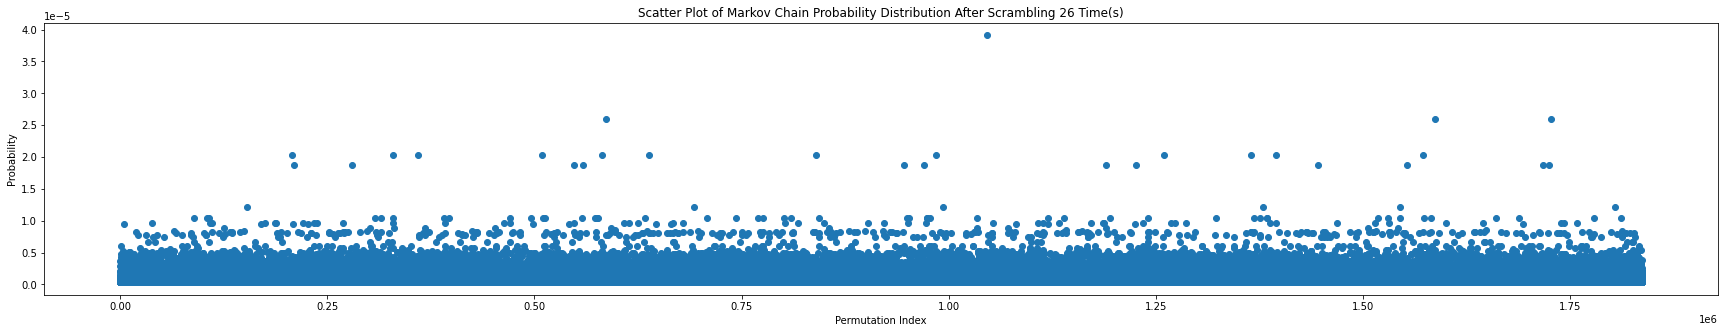

In [228]:
t=26
pi=get_chain_distribution(dim,transition_matrix,t)
values=pi.data
indices=range(len(values))
fig,ax=plt.subplots(figsize=(30,5))
ax.scatter(indices,pi.data)
ax.set_xlabel('Permutation Index')
ax.set_ylabel('Probability')
ax.set_title('Scatter Plot of Markov Chain Probability Distribution After Scrambling {} Time(s)'.format(t))

# References

- https://www.lifehacker.com.au/2020/01/how-hard-is-it-to-scramble-rubiks-cube/
- http://anttila.ca/michael/devilsalgorithm/#:~:text=Definition%3A%20A%20Devil's%20Algorithm%20is,in%20the%20shortest%20Devil's%20Algorithm.